In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/14
    print("準備完了！このまま下のセルを実行できます。")

# 第14章 サンプリング (Sampling)
## 14.2 マルコフ連鎖モンテカルロ法 (Markov Chain Monte Carlo)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第14章「サンプリング」第2節「マルコフ連鎖モンテカルロ法 (MCMC)」に対応する完全な解説・数式導出・図版再現・Python実装です。

---

### 本節の構成と小節一覧
- **14.2.1 メトロポリス法 (The Metropolis algorithm)**: 対称提案分布、受理確率、ステップサイズ問題、拡散的ランダムウォーク律束（式 14.15, Figure 14.9, 14.10, 14.11）
- **14.2.2 マルコフ連鎖 (Markov chains)**: 状態遷移核、定常分布の定義、詳細釣り合い条件とその数学的証明、エルゴード性（式 14.16 〜 14.19）
- **14.2.3 メトロポリス・ヘイスティングス法 (The Metropolis–Hastings algorithm)**: 一般の非対称提案分布への拡張、ヘイスティングス比、詳細釣り合いの厳密証明、MCMC診断（自己相関、積分自己相関時間、有効サンプルサイズ ESS）（式 14.20）
- **14.2.4 ギブスサンプリング (Gibbs sampling)**: 完全条件付き分布からの逐次更新、MH法の受理率100%特殊ケースとしての証明、2次元ガウス分布のギブスサンプリング（式 14.21 〜 14.24）
- **14.2.5 先祖サンプリング (Ancestral sampling)**: 有向グラフィカルモデル (DAG) の因数分解、トポロジカルソート順サンプリング、マルコフブランケット（親・子・共同親）（式 14.25 〜 14.28, Figure 14.12）


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# リポジトリルートを検索パスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "14" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.markov_chain_monte_carlo import (
    metropolis_sampler,
    metropolis_sample_2d_gaussian,
    compute_autocorrelation,
    compute_integrated_autocorrelation_time,
    compute_effective_sample_size_mcmc,
    verify_detailed_balance,
    MetropolisHastingsSampler,
    gibbs_sample_2d_gaussian,
    AncestralSampler,
    generate_figure_14_9,
    generate_figure_14_10,
    generate_figure_14_11,
    generate_figure_14_12,
)

setup_style()
print("Setup complete. Section 14.2 MCMC module loaded successfully.")


Setup complete. Section 14.2 MCMC module loaded successfully.


---

### 14.2.1 メトロポリス法 (The Metropolis algorithm)

棄却サンプリングや重点サンプリングなどの基本サンプリング法は、状態空間の次元 $D$ が増大すると提案分布 $q(z)$ が目標分布 $p(z)$ を覆い尽くせなくなり、受理確率が指数関数的に低下するという「次元の呪い」に直面します。

これに対し、**マルコフ連鎖モンテカルロ法 (MCMC)** は、現在の状態 $z^{(\tau)}$ の近傍に新たな候補点 $z^*$ を提案する局所探索（ローカルウォーク）を行うことで、目標分布の確率質量が集中する「典型集合 (typical set)」に留まりながら高次元空間を探索します。

#### 1. アルゴリズムの手続きと受理確率
メトロポリス法（Metropolis et al., 1953）では、現在の状態 $z$ から提案分布 $q(z^* \mid z)$ に従って候補点 $z^*$ を生成します。ここで提案分布は**対称（symmetric）**であると仮定します：
$$
q(z^* \mid z) = q(z \mid z^*)
$$
典型例として、等方性ガウス分布 $q(z^* \mid z) = \mathcal{N}(z^* \mid z, \rho^2 \mathbf{I})$ などが用いられます。

候補点 $z^*$ の受理確率（Acceptance probability）は次のように定義されます：
$$
A(z^*, z) = \min\left(1, \frac{p(z^*)}{p(z)}\right) = \min\left(1, \exp(\ln p(z^*) - \ln p(z))\right) \tag{14.15}
$$
- $p(z^*) \ge p(z)$ （確率密度が増加する方向）の場合、$A(z^*, z) = 1$ であり**必ず受理**されます。
- $p(z^*) < p(z)$ （確率密度が減少する方向）の場合、$p(z^*) / p(z)$ の確率で受理され、確率 $1 - A(z^*, z)$ で**棄却**されます。
- 棄却された場合、チェーンはその場に留まり、前回のサンプルが重複して複製されます：$z^{(\tau+1)} = z^{(\tau)}$。

この比率計算において正規化定数 $Z = \int \widetilde{p}(z) \, dz$ は分子分母で相殺されるため、未正規化分布 $\widetilde{p}(z)$ のみからサンプリング可能です。

#### Figure 14.9: 2次元相関ガウス分布に対するメトロポリス法
下図は、相関を持つ2次元ガウス分布（楕円は等確率密度輪郭線）に対するメトロポリス法の軌跡です。
受理されたステップは緑色の線分、棄却された提案は赤色のスパイクとして描画されています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_9_metropolis_algorithm.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_9_metropolis_algorithm.png


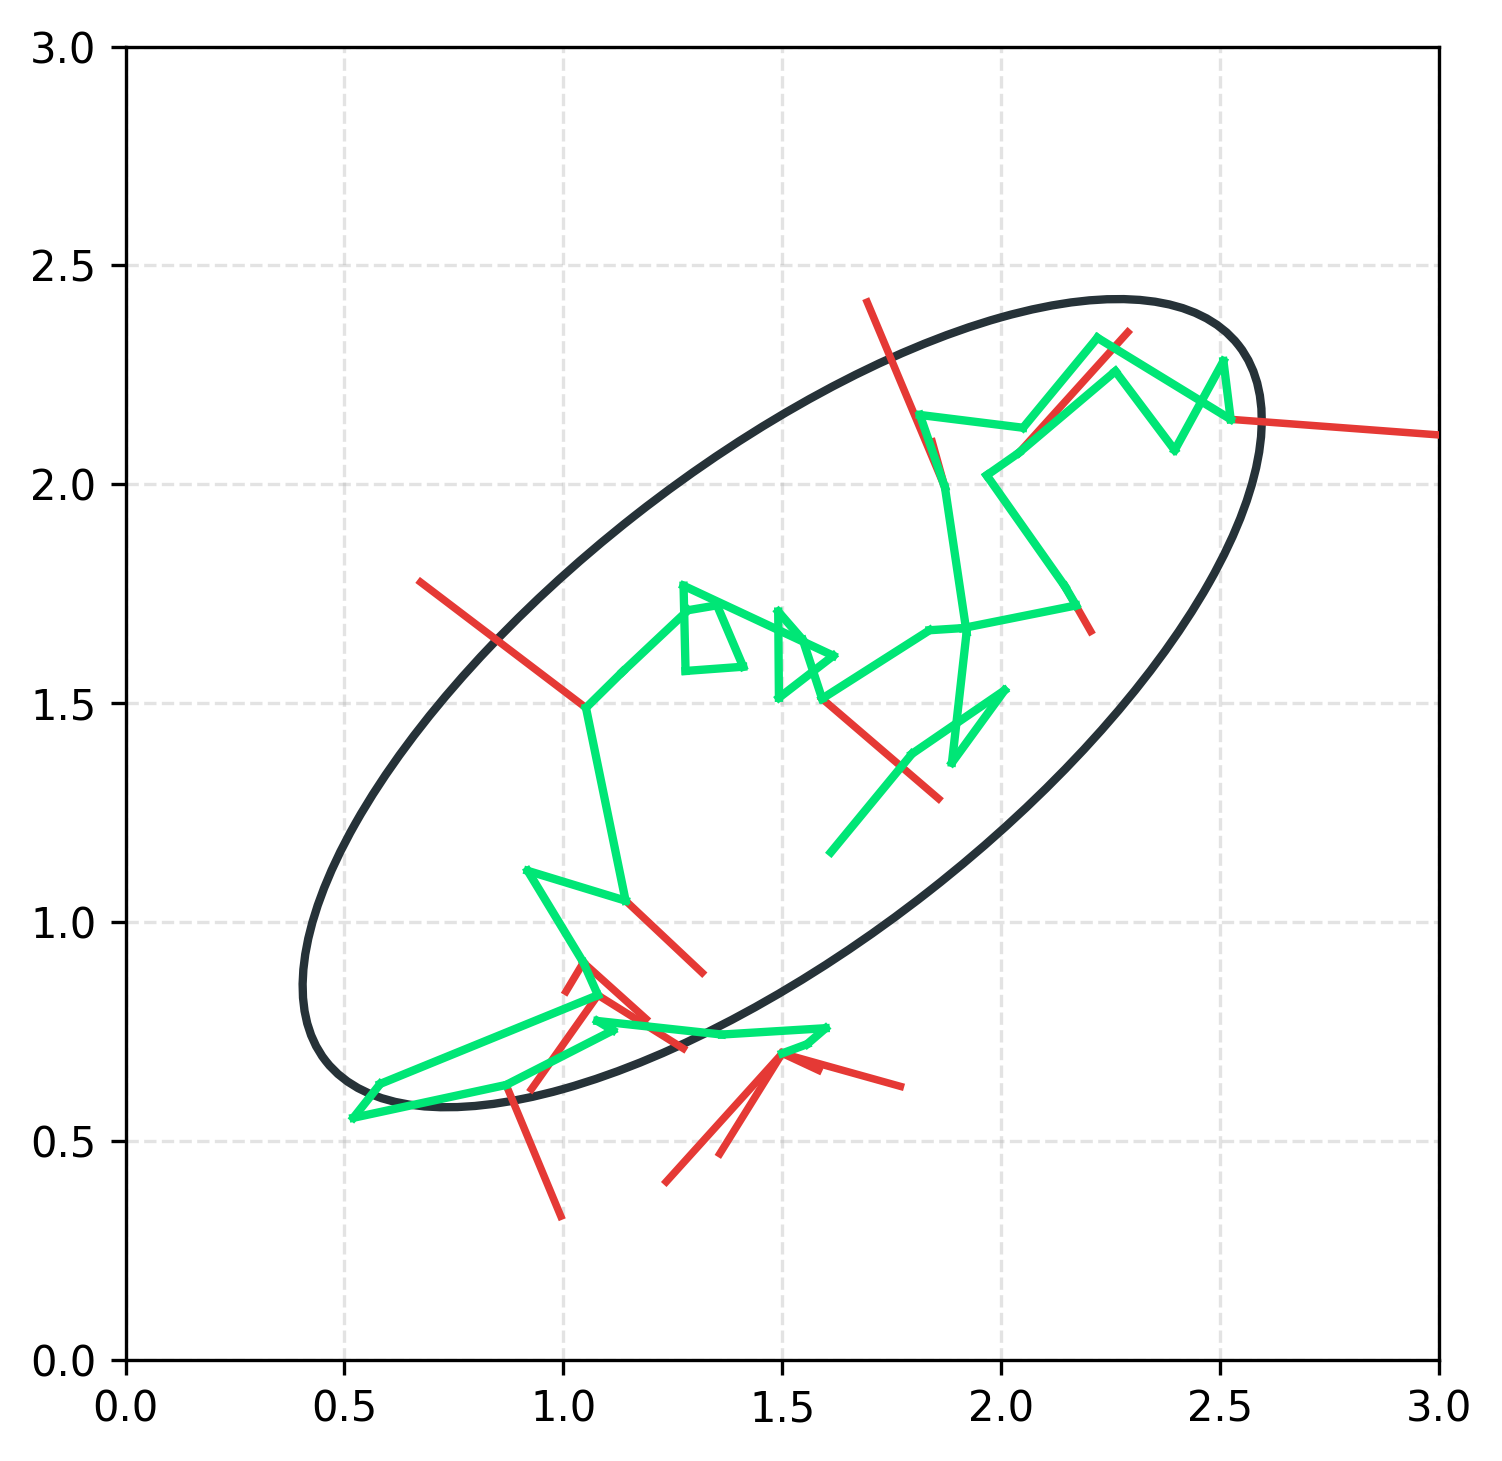

Metropolis acceptance rate: 0.697
Sample mean: [-0.32884364  0.00781921]
Sample cov diagonal: [1.06282418 0.09174124]


In [2]:
# Figure 14.9 の生成と描画
fig14_9 = generate_figure_14_9()
plt.show()

# メトロポリス法の基本動作確認
target_log_p = lambda z: -0.5 * (z[0]**2 / 1.0 + z[1]**2 / 0.1) # 異方性ガウス
res_m = metropolis_sampler(
    target_log_p=target_log_p,
    proposal_std=0.3,
    num_samples=2000,
    init_state=np.array([2.0, 2.0]),
    burn_in=500,
    seed=42
)
print(f"Metropolis acceptance rate: {res_m['acceptance_rate']:.3f}")
print(f"Sample mean: {np.mean(res_m['samples'], axis=0)}")
print(f"Sample cov diagonal: {np.var(res_m['samples'], axis=0)}")


#### 2. ステップサイズ問題と拡散的スケーリング (Diffusive Random Walk)

メトロポリス法の挙動は、提案分布のスケール（ステップサイズ）$\rho$ に極めて強く依存します。

#### Figure 14.10: ステップサイズ $\rho$ と共分散スケール $\sigma_{\min}, \sigma_{\max}$
下図に示すように、異方的な分布（長軸の広がり $\sigma_{\max}$、短軸の広がり $\sigma_{\min}$）において：
- $\rho$ を $\sigma_{\max}$ 程度に大きくすると、短軸方向への提案が低確率領域（等高線の外側）に飛び出すため、提案の大部分が棄却され、チェーンが停滞します（受理率の激減）。
- 受理率を実用的な水準（例えば 20%〜50%）に保つためには、ステップサイズ $\rho$ を短軸スケール $\sigma_{\min}$ 程度に小さく抑える必要があります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_10_step_size_scaling.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_10_step_size_scaling.png


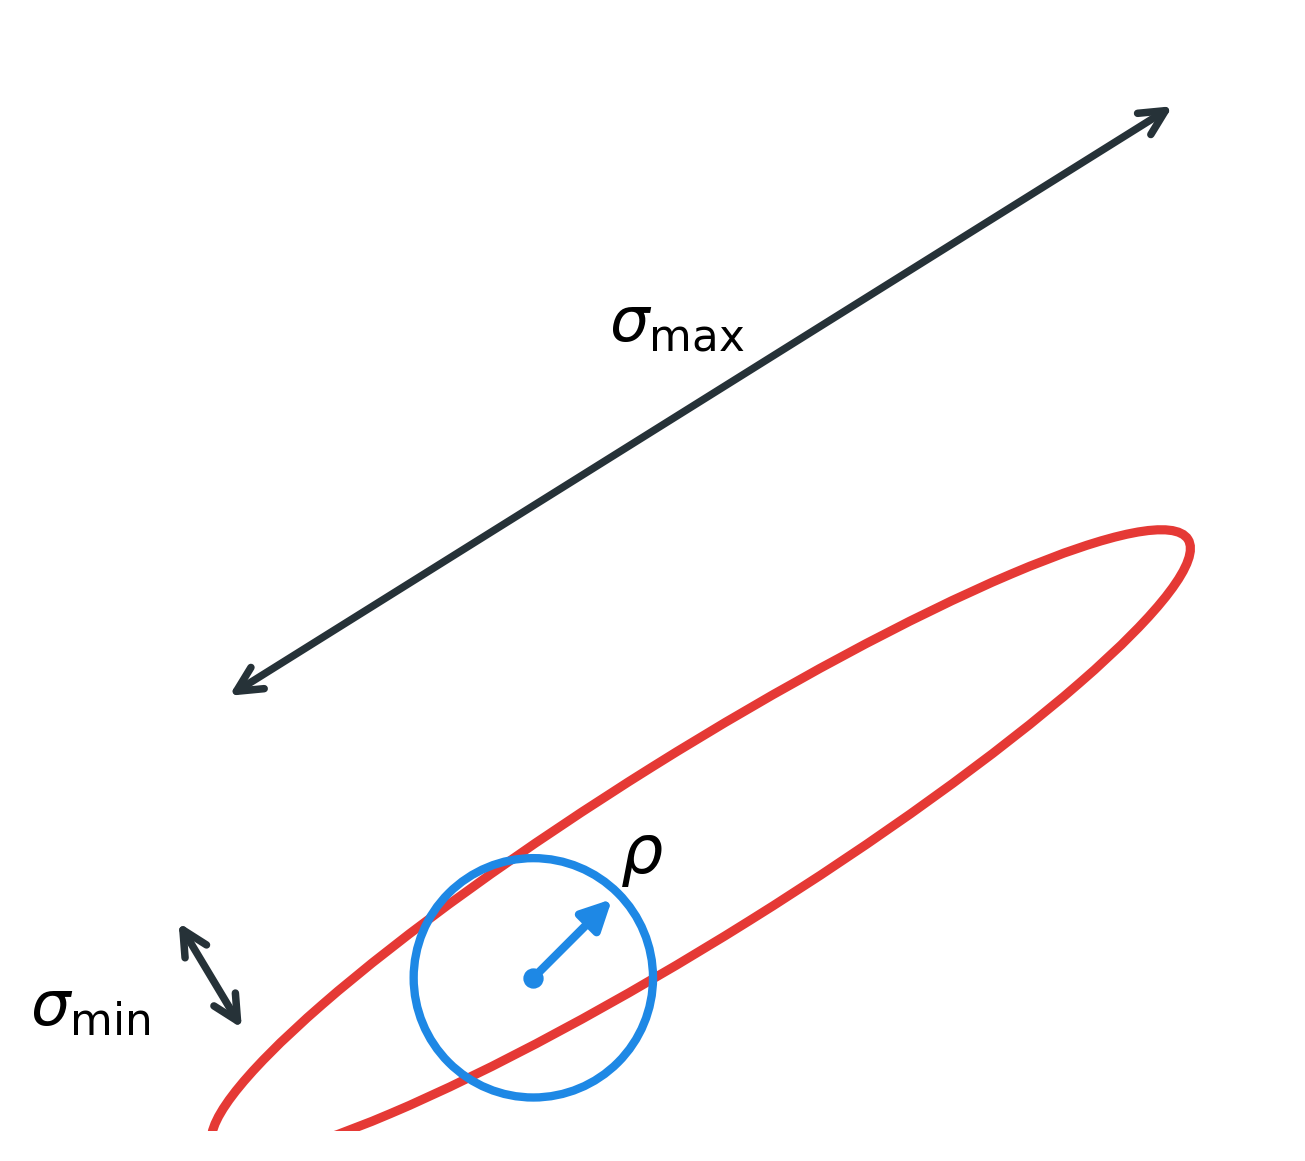

In [3]:
# Figure 14.10 の生成と描画
fig14_10 = generate_figure_14_10()
plt.show()


#### Figure 14.11: 拡散的ランダムウォークによる遅延
ステップサイズ $\rho$ が $\sigma_{\min}$（図中の $l$）に制限されると、長軸方向（長さ $L$）の探索はランダムウォークによる拡散（Diffusion）に従います。

ランダムウォークにおいて、1ステップの移動距離が $l$ であるとき、$N$ ステップ後の平均二乗変位は $\mathbb{E}[(\Delta z)^2] = N l^2$ となります。
したがって、長軸の長さ $L$ を踏破して相関のない独立なサンプルを得るために必要なステップ数は：
$$
N \sim \left(\frac{L}{l}\right)^2
$$
すなわち、比率 $L/l$ の2乗に比例して膨大なステップ数が必要となります。これがメトロポリス法の根本的なボトルネック（拡散的律束）であり、後のハイブリッドモンテカルロ法 (HMC) やランジュバンサンプリングへと発展する動機となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_11_diffusive_scaling.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_11_diffusive_scaling.png


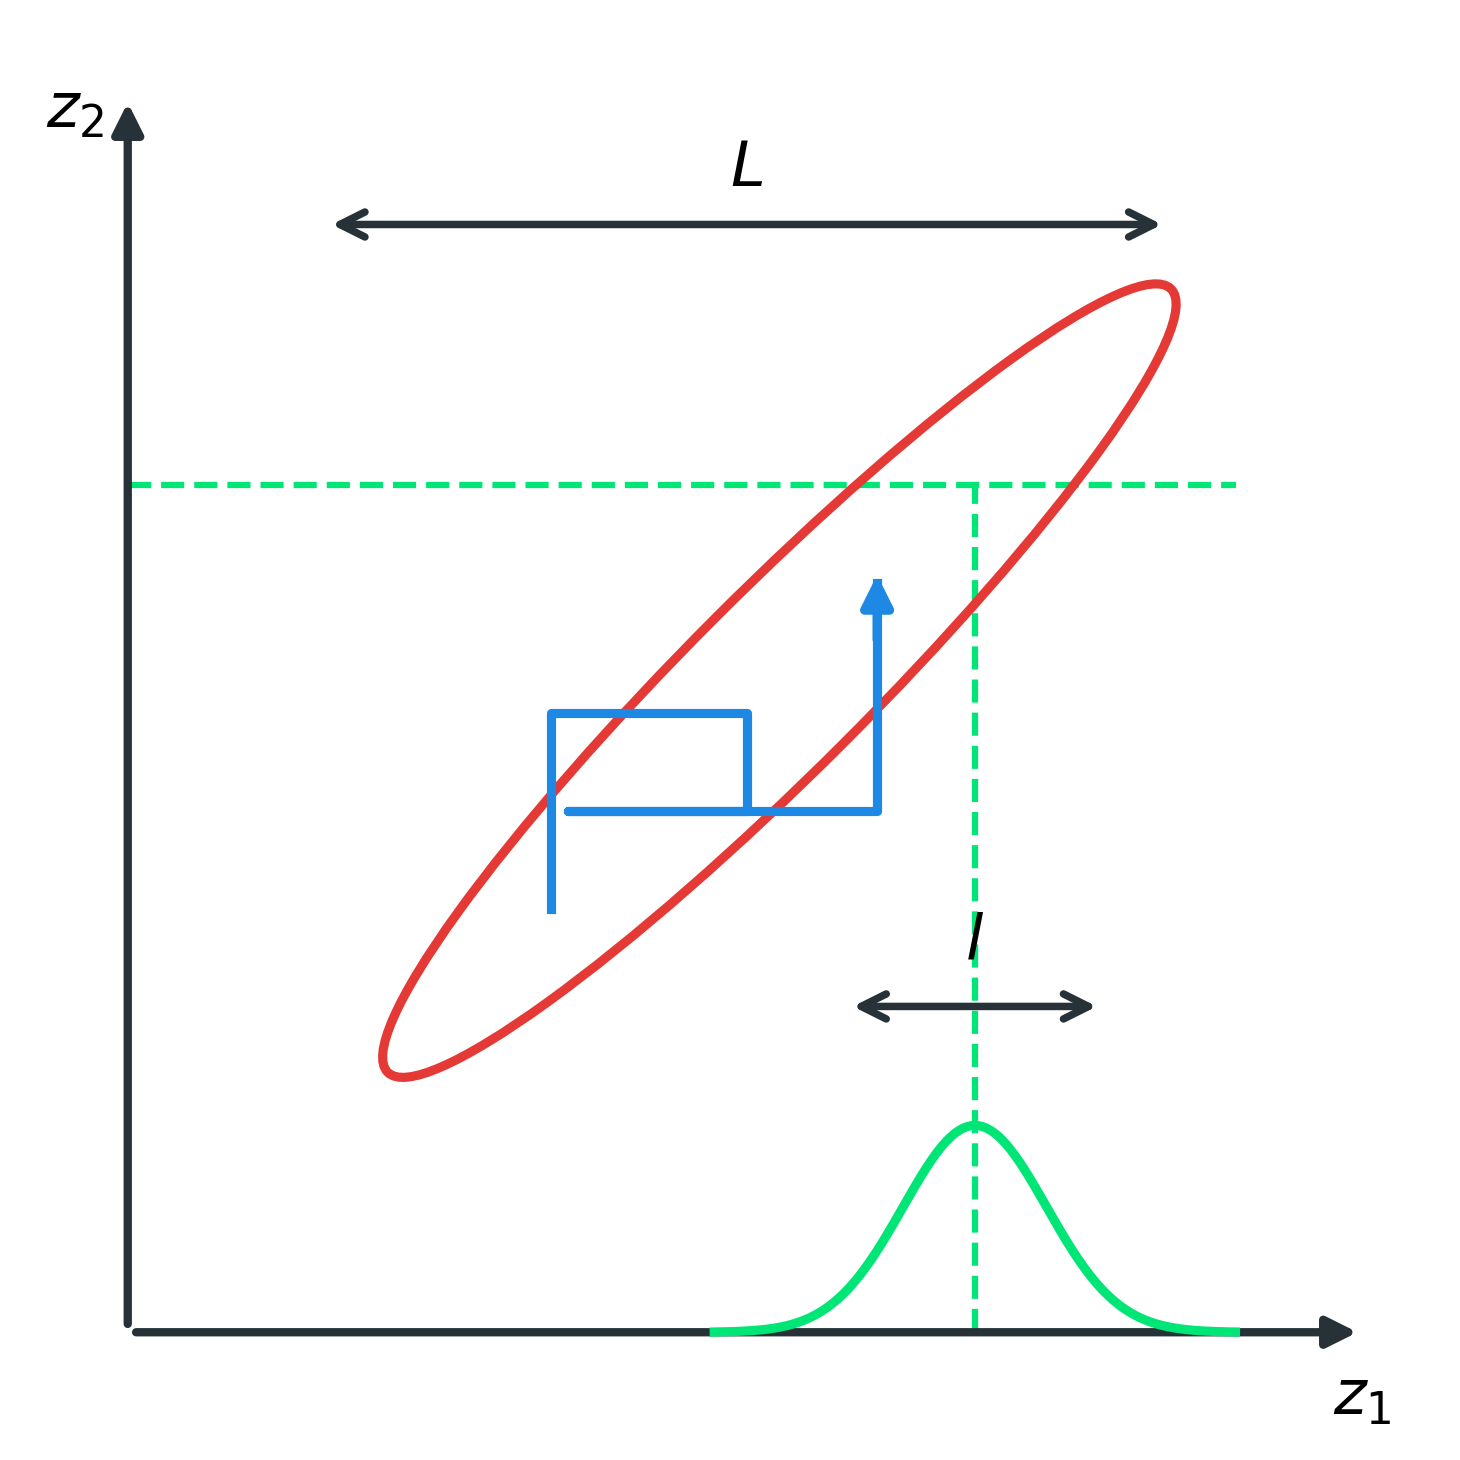

In [4]:
# Figure 14.11 の生成と描画
fig14_11 = generate_figure_14_11()
plt.show()


---

### 14.2.2 マルコフ連鎖と詳細釣り合い (Markov Chains and Detailed Balance)

MCMCが目標分布 $p(z)$ からの正しいサンプルを生成する数学的根拠は、**マルコフ連鎖の収束理論**と**詳細釣り合い条件**に基づいています。

#### 1. マルコフ連鎖の定義
一連の確率変数列 $z^{(1)}, z^{(2)}, \dots, z^{(m)}$ において、次の状態の条件付き確率が直前の状態のみに依存するとき、これを1階マルコフ連鎖と呼びます：
$$
p(z^{(m+1)} \mid z^{(1)}, \dots, z^{(m)}) = T(z^{(m)}, z^{(m+1)}) \tag{14.16}
$$
ここで $T(z, z^*)$ は状態 $z$ から $z^*$ への**遷移確率核 (transition probability kernel)** であり、$\int T(z, z^*) \, dz^* = 1$ を満たします。

#### 2. 不変分布（定常分布）の定義
ある確率分布 $p^*(z)$ が遷移核 $T$ に対して次の条件を満たすとき、$p^*(z)$ をマルコフ連鎖の**不変分布 (invariant distribution)** または**定常分布 (stationary distribution)** と呼びます：
$$
p^*(z) = \int p^*(z') T(z', z) \, dz' \tag{14.17}
$$
離散状態空間では、定常確率ベクトル $\boldsymbol{\pi}^*$ は遷移確率行列 $\mathbf{T}$ の左固有ベクトル $\boldsymbol{\pi}^{*T} = \boldsymbol{\pi}^{*T} \mathbf{T}$（固有値 1）に対応します。

#### 3. 詳細釣り合い条件 (Detailed Balance Condition)
マルコフ連鎖が目的の定常分布 $p(z)$ を持つための十分条件が**詳細釣り合い（局所釣り合い）**です：
$$
p(z) T(z, z^*) = p(z^*) T(z^*, z) \tag{14.18}
$$
物理的には、状態 $z$ から $z^*$ への微視的確率流（Flux）と、逆向きの遷移 $z^* \to z$ の確率流が完全に均衡していることを意味します。

#### 【定理】詳細釣り合いを満たす分布は定常分布である
（証明）
詳細釣り合い条件の両辺を $z$ について積分すると：
$$
\int p(z) T(z, z^*) \, dz = \int p(z^*) T(z^*, z) \, dz = p(z^*) \int T(z^*, z) \, dz
$$
ここで遷移確率の定義より $\int T(z^*, z) \, dz = 1$ であるため、
$$
\int p(z) T(z, z^*) \, dz = p(z^*) \cdot 1 = p(z^*) \tag{14.19}
$$
となり、式 (14.17) の定常分布の条件が厳密に成立します。（Q.E.D.）

#### 4. エルゴード性 (Ergodicity)
定常分布が存在するだけでなく、任意の初期状態 $z^{(0)}$ から出発したチェーンが漸近的に一意の定常分布 $p(z)$ に収束するためには、マルコフ連鎖が**エルゴード的 (ergodic)** である必要があります。
連続空間におけるエルゴード性の十分条件は：
1. **既約性 (Irreducibility)**: 有限ステップの遷移により、目標分布の台（サポート）内の任意の領域から任意の領域へ到達できること。
2. **非周期性 (Aperiodicity)**: チェーンが固定された周期的な軌道に捕捉されないこと。


In [5]:
# 詳細釣り合いの数値検証
# ガウス分布目標 p(z) と対称遷移核 T(z -> z*) における微視的確率流の釣り合い
def target_pdf(z):
    return float(np.exp(-0.5 * (z**2)))

def transition_kernel(z_from, z_to, proposal_std=1.0):
    q = stats.norm.pdf(z_to, loc=z_from, scale=proposal_std)
    alpha = min(1.0, target_pdf(z_to) / target_pdf(z_from))
    return float(q * alpha)

z_a, z_b = 0.5, 1.8
db_check = verify_detailed_balance(
    target_p=target_pdf,
    transition_p=transition_kernel,
    z_a=z_a,
    z_b=z_b
)
print("=== Detailed Balance Verification ===")
print(f"Point z_a: {z_a}, Point z_b: {z_b}")
print(f"Flux z_a -> z_b: {db_check['flux_ab']:.8f}")
print(f"Flux z_b -> z_a: {db_check['flux_ba']:.8f}")
print(f"Difference:      {db_check['difference']:.2e}")
print(f"Is balanced?     {db_check['is_balanced']}")


=== Detailed Balance Verification ===
Point z_a: 0.5, Point z_b: 1.8
Flux z_a -> z_b: 0.03391362
Flux z_b -> z_a: 0.03391362
Difference:      6.94e-18
Is balanced?     True


---

### 14.2.3 メトロポリス・ヘイスティングス法 (The Metropolis–Hastings algorithm)

ヘイスティングス（Hastings, 1970）は、メトロポリス法を**非対称な提案分布 $q(z^* \mid z) \neq q(z \mid z^*)$** に対しても適用できるように一般化しました。

#### 1. 一般の受理確率とヘイスティングス比
非対称提案分布を用いる場合、提案自体の偏り（例えばある方向への遷移が提案されやすい傾向）を補正する必要があります。
受理確率 $A(z^*, z)$ は次のように修正されます：
$$
A(z^*, z) = \min\left(1, \frac{p(z^*) q(z \mid z^*)}{p(z) q(z^* \mid z)}\right) \tag{14.20}
$$
提案分布が対称 $q(z^* \mid z) = q(z \mid z^*)$ のとき、式 (14.20) はメトロポリス法の式 (14.15) に完全に帰着されます。

#### 2. 詳細釣り合いの完全な証明
（証明）
状態 $z \neq z^*$ 間の実効遷移核は $T(z, z^*) = q(z^* \mid z) A(z^*, z)$ です。
一般性を失うことなく、
$$
p(z) q(z^* \mid z) \ge p(z^*) q(z \mid z^*)
$$
と仮定します。このとき、
$$
A(z^*, z) = \frac{p(z^*) q(z \mid z^*)}{p(z) q(z^* \mid z)} \le 1
$$
一方、逆向きの遷移の受理確率は：
$$
A(z, z^*) = \min\left(1, \frac{p(z) q(z^* \mid z)}{p(z^*) q(z \mid z^*)}\right) = 1
$$
したがって、順方向の確率流は：
$$
p(z) T(z, z^*) = p(z) q(z^* \mid z) A(z^*, z) = p(z) q(z^* \mid z) \frac{p(z^*) q(z \mid z^*)}{p(z) q(z^* \mid z)} = p(z^*) q(z \mid z^*)
$$
逆方向の確率流は：
$$
p(z^*) T(z^*, z) = p(z^*) q(z \mid z^*) A(z, z^*) = p(z^*) q(z \mid z^*) \cdot 1 = p(z^*) q(z \mid z^*)
$$
両者は完全に一致するため、$p(z) T(z, z^*) = p(z^*) T(z^*, z)$ が恒等的に成り立ちます。（Q.E.D.）

#### 3. MCMCチェーンの診断指標
MCMCで得られたサンプル列 $\{z^{(\tau)}\}$ は独立ではなく、相関（自己相関）を持ちます。
1. **自己相関関数 (Autocorrelation Function, ACF)**:
   $$
   \rho_k = \frac{\sum_{\tau=1}^{N-k} (z^{(\tau)} - \bar{z})(z^{(\tau+k)} - \bar{z})}{\sum_{\tau=1}^N (z^{(\tau)} - \bar{z})^2}
   $$
2. **積分自己相関時間 (Integrated Autocorrelation Time, $\tau_{\text{int}}$)**:
   $$
   \tau_{\text{int}} = 1 + 2 \sum_{k=1}^\infty \rho_k
   $$
3. **有効サンプルサイズ (Effective Sample Size, ESS)**:
   $$
   N_{\text{eff}} = \frac{N}{\tau_{\text{int}}}
   $$
   これは、$N$ 個の相関を持つMCMCサンプルが、独立同分布サンプル何個分に相当するかを表す指標です。


Acceptance rate: 0.785
Sample Mean (True = 3.0): 3.029
Sample Var  (True = 3.0): 3.399
Integrated Autocorrelation Time tau_int: 13.89
Effective Sample Size (ESS): 720.0 / 10000


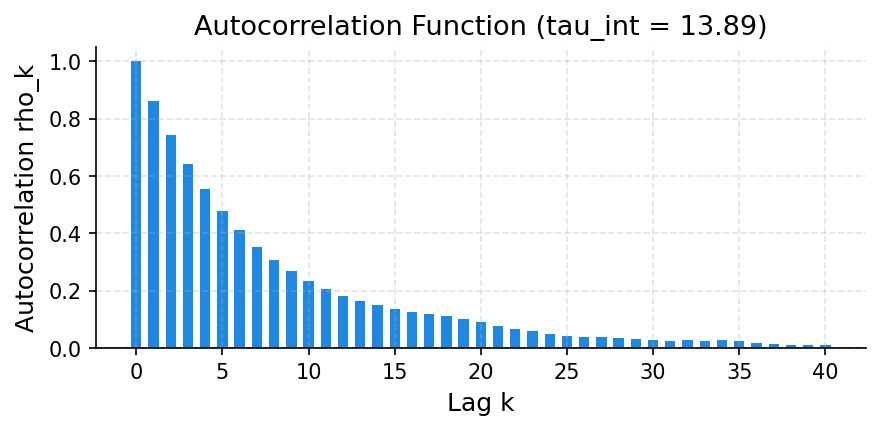

In [6]:
# 非対称提案分布（対数正規提案）を用いたガンマ分布 Gam(3, 1) のサンプリング
alpha, beta = 3.0, 1.0
log_gamma_target = lambda z: (alpha - 1) * np.log(max(1e-12, z[0])) - beta * z[0] if z[0] > 0 else -np.inf

# 対数正規提案: ln z* ~ N(ln z, sigma^2)
sigma_prop = 0.4
def sample_lognormal_prop(z, rng):
    return np.array([np.exp(np.log(z[0]) + rng.randn() * sigma_prop)])

def log_q_lognormal(z_to, z_from):
    if z_to[0] <= 0: return -np.inf
    diff = np.log(z_to[0]) - np.log(z_from[0])
    return -np.log(z_to[0]) - 0.5 * (diff / sigma_prop)**2

mh_sampler = MetropolisHastingsSampler(
    target_log_p=log_gamma_target,
    proposal_sample=sample_lognormal_prop,
    proposal_log_q=log_q_lognormal,
)

mh_res = mh_sampler.sample(num_samples=10000, init_state=np.array([1.0]), burn_in=2000, seed=123)
gamma_samples = mh_res["samples"].flatten()

# MCMC 診断指標の算出
acf = compute_autocorrelation(gamma_samples, max_lag=40)
tau_int = compute_integrated_autocorrelation_time(gamma_samples, max_lag=40)
ess = compute_effective_sample_size_mcmc(gamma_samples, max_lag=40)

print(f"Acceptance rate: {mh_res['acceptance_rate']:.3f}")
print(f"Sample Mean (True = {alpha/beta:.1f}): {np.mean(gamma_samples):.3f}")
print(f"Sample Var  (True = {alpha/(beta**2):.1f}): {np.var(gamma_samples):.3f}")
print(f"Integrated Autocorrelation Time tau_int: {tau_int:.2f}")
print(f"Effective Sample Size (ESS): {ess:.1f} / {len(gamma_samples)}")

# ACF プロット
plt.figure(figsize=(6, 3), dpi=150)
plt.bar(range(len(acf)), acf, color="#1e88e5", width=0.6)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title(f"Autocorrelation Function (tau_int = {tau_int:.2f})")
plt.xlabel("Lag k")
plt.ylabel("Autocorrelation rho_k")
plt.tight_layout()
plt.show()


---

### 14.2.4 ギブスサンプリング (Gibbs sampling)

ギブスサンプリング（Geman & Geman, 1984）は、多変量確率変数 $\mathbf{z} = (z_1, \dots, z_D)^T$ からサンプリングを行う極めて簡潔かつ強力なMCMCアルゴリズムです。

#### 1. アルゴリズムの手続き
各ステップにおいて、1つの変数 $z_i$ を、他のすべての変数の現在の値 $\mathbf{z}_{-i} = \{z_j \mid j \neq i\}$ を条件とする**完全条件付き分布 (full conditional distribution)** からサンプリングします：
$$
\begin{aligned}
z_1^{(\tau+1)} &\sim p(z_1 \mid z_2^{(\tau)}, z_3^{(\tau)}, \dots, z_D^{(\tau)}) \tag{14.21} \\
z_2^{(\tau+1)} &\sim p(z_2 \mid z_1^{(\tau+1)}, z_3^{(\tau)}, \dots, z_D^{(\tau)}) \tag{14.22} \\
&\;\;\vdots \\
z_i^{(\tau+1)} &\sim p(z_i \mid z_1^{(\tau+1)}, \dots, z_{i-1}^{(\tau+1)}, z_{i+1}^{(\tau)}, \dots, z_D^{(\tau)}) \tag{14.23} \\
&\;\;\vdots \\
z_D^{(\tau+1)} &\sim p(z_D \mid z_1^{(\tau+1)}, z_2^{(\tau+1)}, \dots, z_{D-1}^{(\tau+1)}) \tag{14.24}
\end{aligned}
$$

#### 2. MH法の特殊ケースとしての受理率 100% 証明
ギブスサンプリングは、メトロポリス・ヘイスティングス法の特別な場合とみなすことができます。
第 $i$ 成分の更新における提案分布を次のように置きます：
$$
q(\mathbf{z}^* \mid \mathbf{z}) = p(z_i^* \mid \mathbf{z}_{-i}) \mathbb{I}(\mathbf{z}_{-i}^* = \mathbf{z}_{-i})
$$
このとき、目標結合分布は乗法定理より $p(\mathbf{z}) = p(z_i \mid \mathbf{z}_{-i}) p(\mathbf{z}_{-i})$ と分解できます。
これをMH法の受理確率式 (14.20) に代入すると：
$$
A(\mathbf{z}^*, \mathbf{z}) = \frac{p(\mathbf{z}^*) q(\mathbf{z} \mid \mathbf{z}^*)}{p(\mathbf{z}) q(\mathbf{z}^* \mid \mathbf{z})} = \frac{p(z_i^* \mid \mathbf{z}_{-i}^*) p(\mathbf{z}_{-i}^*) \cdot p(z_i \mid \mathbf{z}_{-i}^*)}{p(z_i \mid \mathbf{z}_{-i}) p(\mathbf{z}_{-i}) \cdot p(z_i^* \mid \mathbf{z}_{-i})}
$$
ここで $\mathbf{z}_{-i}^* = \mathbf{z}_{-i}$ であるため、$p(\mathbf{z}_{-i}^*) = p(\mathbf{z}_{-i})$ および $p(z_i \mid \mathbf{z}_{-i}^*) = p(z_i \mid \mathbf{z}_{-i})$ となり、すべての項が完全に相殺されます：
$$
A(\mathbf{z}^*, \mathbf{z}) = 1.0
$$
すなわち、**ギブスサンプリングにおけるすべての提案は 100% 受理され、棄却が一切発生しない**という極めて優美な性質を持ちます。


Sample mean: [1.60705875 1.61175576]
Sample cov:
[[0.49613899 0.38592886]
 [0.38592886 0.4900366 ]]


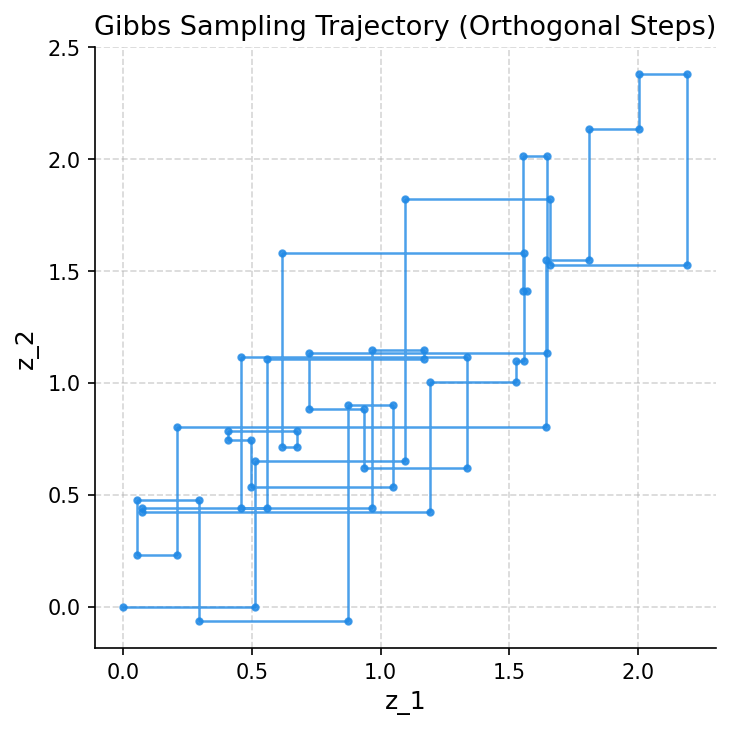

In [7]:
# 2次元相関ガウス分布に対するギブスサンプリングの実装と可視化
mean_gibbs = np.array([1.5, 1.5])
cov_gibbs = np.array([[0.5, 0.4], [0.4, 0.5]])

gibbs_res = gibbs_sample_2d_gaussian(
    mean=mean_gibbs,
    cov=cov_gibbs,
    num_steps=1000,
    init_state=np.array([0.0, 0.0]),
    seed=42,
)

gibbs_samples = gibbs_res["samples"][200:]
print(f"Sample mean: {np.mean(gibbs_samples, axis=0)}")
print(f"Sample cov:\n{np.cov(gibbs_samples, rowvar=False)}")

# 最初の30ステップの直交（マンハッタン型）軌跡の可視化
trajectory = gibbs_res["trajectory"][:60]
plt.figure(figsize=(5, 5), dpi=150)
plt.plot(trajectory[:, 0], trajectory[:, 1], color="#1e88e5", marker="o", markersize=3, linewidth=1.2, alpha=0.8)
plt.title("Gibbs Sampling Trajectory (Orthogonal Steps)")
plt.xlabel("z_1")
plt.ylabel("z_2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


---

### 14.2.5 有向グラフィカルモデルにおける先祖サンプリング (Ancestral sampling)

有向非循環グラフ（DAG: Directed Acyclic Graph）で表現される有向確率的グラフィカルモデル（ベイジアンネットワーク）では、結合分布は各ノードの親ノードを条件とする局所条件付き分布の積に因数分解されます：
$$
p(\mathbf{z}) = \prod_{i=1}^N p(z_i \mid \text{pa}_i) \tag{14.25}
$$
ここで $\text{pa}_i$ はノード $i$ の親ノード（parents）集合を表します。

#### 1. 先祖サンプリング (Ancestral Sampling) の手続き
DAGの因数分解構造を利用すると、**先祖サンプリング**により結合分布から直接かつ厳密にサンプルを抽出できます：
1. グラフの有向辺の向きに従って、ノードをトポロジカルソート順（先祖から子孫へ）に整列します：$z_1, z_2, \dots, z_N$。
2. 親を持たない根ノード（ルートノード）から順に、周辺分布 $p(z_1)$ からサンプリングします。
3. 続く各ノード $z_i$ は、すでにサンプリングされた親ノードの値 $\widehat{\text{pa}}_i$ を代入した条件付き分布 $p(z_i \mid \widehat{\text{pa}}_i)$ から順次サンプリングします。
棄却も自己相関も生じず、得られるサンプルは結合分布からの完全な独立同分布（i.i.d.）標本となります。

#### 2. マルコフブランケット (Markov blanket) とギブスサンプリング
グラフィカルモデルにおいてギブスサンプリングを適用する場合、ノード $\mathbf{z}$ の完全条件付き分布 $p(\mathbf{z} \mid \mathbf{z}_{-\mathbf{z}})$ は、グラフ全体ではなく**マルコフブランケット (Markov blanket)** $\text{mb}(\mathbf{z})$ にのみ依存します：
$$
p(\mathbf{z} \mid \mathbf{z}_{-\mathbf{z}}) = p(\mathbf{z} \mid \text{mb}(\mathbf{z})) \tag{14.26}
$$
結合分布の因数分解より：
$$
p(\mathbf{z} \mid \mathbf{z}_{-\mathbf{z}}) \propto p(\mathbf{z}, \mathbf{z}_{-\mathbf{z}}) = \prod_{k=1}^N p(z_k \mid \text{pa}_k) \tag{14.27}
$$
右辺の積の中で、$\mathbf{z}$ を含む因子のみを抽出すると：
$$
p(\mathbf{z} \mid \text{mb}(\mathbf{z})) \propto p(\mathbf{z} \mid \text{pa}_{\mathbf{z}}) \prod_{k \in \text{ch}_{\mathbf{z}}} p(z_k \mid \text{pa}_k) \tag{14.28}
$$
したがって、ノード $\mathbf{z}$ のマルコフブランケットは以下のノード集合から構成されます：
1. **親ノード群 (Parents)**: $\text{pa}_{\mathbf{z}}$
2. **子ノード群 (Children)**: $\text{ch}_{\mathbf{z}}$
3. **子の他の親ノード群 (Co-parents)**: 子ノードを共有する他の親ノード群

#### Figure 14.12: マルコフブランケットの構造
下図は、中心ノード $\mathbf{z}$（白色ノード）のマルコフブランケット（青色背景・赤色境界で囲まれたノード群）を示しています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_12_markov_blanket.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_12_markov_blanket.png


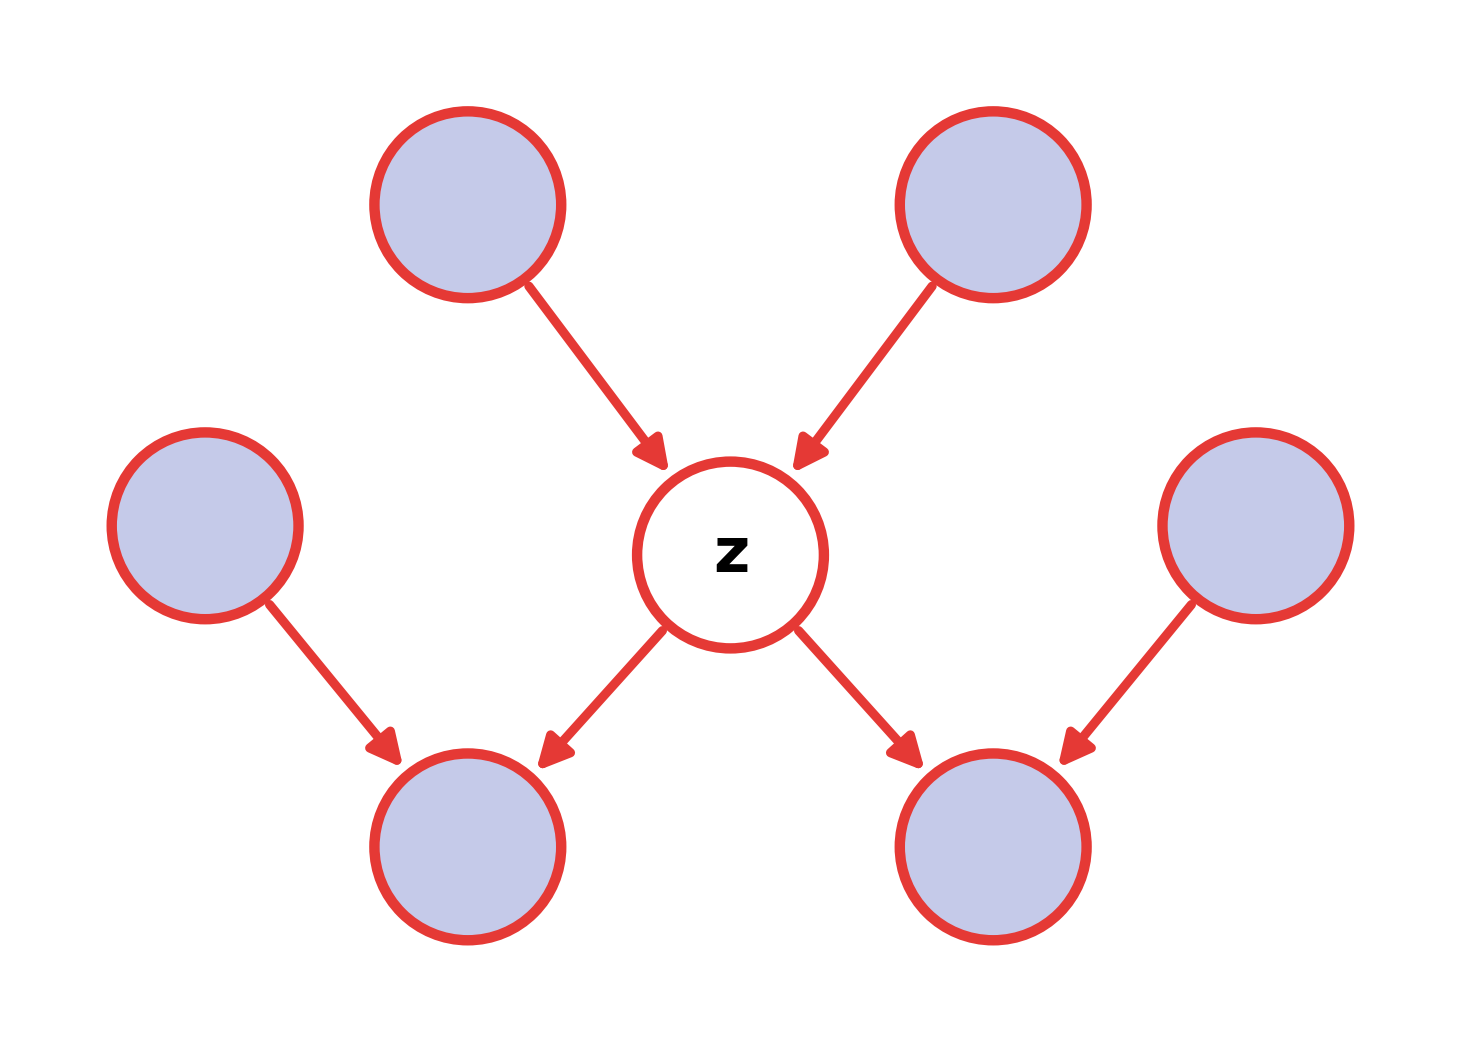

E[X] (True = 0.60): 0.605
E[Y] (True = 1.20): 1.202
E[Z] (True = 0.20): 0.199


In [8]:
# Figure 14.12 の生成と描画
fig14_12 = generate_figure_14_12()
plt.show()

# 先祖サンプリングの動作検証 (3ノード DAG: X -> Y -> Z)
def sample_x(parents, rng):
    return rng.choice([0, 1], p=[0.4, 0.6])

def sample_y(parents, rng):
    x = parents["X"]
    return rng.normal(loc=2.0 * x, scale=0.5)

def sample_z(parents, rng):
    y = parents["Y"]
    return rng.normal(loc=y - 1.0, scale=0.3)

dag_sampler = AncestralSampler(
    topo_order=["X", "Y", "Z"],
    conditionals={"X": sample_x, "Y": sample_y, "Z": sample_z}
)

dag_samples = dag_sampler.sample(num_samples=5000, seed=42)
x_vals = np.array([s["X"] for s in dag_samples])
y_vals = np.array([s["Y"] for s in dag_samples])
z_vals = np.array([s["Z"] for s in dag_samples])

print(f"E[X] (True = 0.60): {np.mean(x_vals):.3f}")
print(f"E[Y] (True = 1.20): {np.mean(y_vals):.3f}")
print(f"E[Z] (True = 0.20): {np.mean(z_vals):.3f}")


---

### 14.2.6 まとめ (Summary and Perspectives)

1. **メトロポリス法**: 対称提案分布 $q(z^* \mid z) = q(z \mid z^*)$ を用い、局所探索により高次元の典型集合を効率よく探索する。
2. **ステップサイズと拡散律束**: 提案スケール $\rho$ は最小分散 $\sigma_{\min}$ に制約され、長軸方向 $L$ の探索は $(L/\sigma_{\min})^2$ の拡散的ランダムウォーク律束を受ける。
3. **詳細釣り合い条件**: $p(z) T(z, z^*) = p(z^*) T(z^*, z)$ を満たすマルコフ連鎖は、目標分布 $p(z)$ を定常分布として持つ。
4. **メトロポリス・ヘイスティングス法**: 非対称提案分布 $q(z^* \mid z)$ を導入し、ヘイスティングス比により詳細釣り合いを完全に保持する。
5. **ギブスサンプリング**: 完全条件付き分布 $p(z_i \mid \mathbf{z}_{-i})$ からの逐次サンプリングであり、受理率 100%（棄却率 0%）のMH法として解釈できる。
6. **先祖サンプリングとマルコフブランケット**: DAGにおける厳密な順方向サンプリングを可能にし、グラフィカルモデルにおけるギブス更新は局所的なマルコフブランケット（親・子・共同親）のみに依存する。
